**task 4 of Pandahat Adverserial Learning Path but with FGSM:** 

This will effectively be the same as task 4 but with applying the adverserial attack known as Fast Gradient Sign Method. So I wont be adding much to this .-.

# Convolutional Neural Network under FGSM

Imports:

In [1]:
import numpy as np
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import seaborn as sns
import random


class mapping/id mapping:

In [2]:
class_to_id = {
    "Water/Cloud": 0,
    "Bare Soil": 1,
    "Sparse Vegetation": 2,
    "Dense Vegetation": 3
}

Sample loader:

In [3]:
base_dir = os.path.join(os.getcwd(), "..")
labels_path = os.path.join(base_dir, "labels")
samples_path = os.path.join(base_dir, "samples")

sample_files = sorted(glob.glob(os.path.join(samples_path, "*.tiff")))
label_files = sorted(glob.glob(os.path.join(labels_path,  "*.tiff")))
print(f"Found {len(sample_files)} samples, {len(label_files)} labels")

Found 614 samples, 614 labels


sample and label augmentation function:

In [4]:
# Literally as I'm about to submit this I look at the PyTorch docs and it does all of this already .-.
# Should've looked at the docs a bit longer.

def augment_pair(image_pil, label_pil):
    # Horizontal flip
    if random.random() < 0.5:
        image_pil = TF.hflip(image_pil)
        label_pil = TF.hflip(label_pil)

    # Vertical flip
    if random.random() < 0.5:
        image_pil = TF.vflip(image_pil)
        label_pil = TF.vflip(label_pil)

    # Rotate
    if random.random() < 0.5:
        angle = random.uniform(-30, 30)
        image_pil = TF.rotate(image_pil, angle, fill=0)
        label_pil = TF.rotate(label_pil, angle, fill=0)

    # Scale
    if random.random() < 0.5:
        scale = random.uniform(0.9, 1.1)
        translate_x = random.uniform(-0.1, 0.1) * 256
        translate_y = random.uniform(-0.1, 0.1) * 256
        image_pil = TF.affine(image_pil, angle=0, translate=[translate_x, translate_y], scale=scale, shear=0, fill=0)
        label_pil = TF.affine(label_pil, angle=0, translate=[translate_x, translate_y], scale=scale, shear=0, fill=0)
    
    # Brightness and contrast (doesn't apply to labels as that would corrupt them)
    if random.random() < 0.5:
        brightness_factor = random.uniform(0.7, 1.3)
        image_pil = TF.adjust_brightness(image_pil, brightness_factor)

    if random.random() < 0.5:
        contrast_factor = random.uniform(0.8, 1.2)
        image_pil = TF.adjust_contrast(image_pil, contrast_factor)

    return image_pil, label_pil




Extracting patches and assigning classes:

In [5]:
PATCH_SIZE = 32
HALF = PATCH_SIZE // 2  
PATCHES_PER_IMAGE = 50   

def extract_patches_original(img_array, label_array, n_patches):
    ndvi = (label_array / 255.0) * 2 - 1
    print(f"ndvi shape: {ndvi.shape}, img shape: {img_array.shape}")
    H, W = img_array.shape[:2]
    rows = np.random.randint(HALF, H - HALF, size=n_patches)
    cols = np.random.randint(HALF, W - HALF, size=n_patches)
    patches = []
    for r, c in zip(rows, cols):
        patch = img_array[r-HALF:r+HALF, c-HALF:c+HALF, :]
        print(f"patch shape: {patch.shape}")  
        if patch.shape != (PATCH_SIZE, PATCH_SIZE, 3):
            continue
        ndvi_val = ndvi[r, c]
        if ndvi_val < 0:   
            veg_class = "Water/Cloud"
        elif ndvi_val < 0.2: 
            veg_class = "Bare Soil"
        elif ndvi_val < 0.5: 
            veg_class = "Sparse Vegetation"
        else:                
            veg_class = "Dense Vegetation"
        patches.append((patch, class_to_id[veg_class]))
    return patches

def extract_patches_augmented(img_array, label_array, n_patches):
    # takes the image and augments it to then extract patches from the result
    img_pil = Image.fromarray(img_array.astype(np.uint8))
    label_pil = Image.fromarray(label_array.astype(np.uint8))
    img_pil, label_pil = augment_pair(img_pil, label_pil)
    img_array = np.array(img_pil)
    label_array = np.array(label_pil)

    return extract_patches_original(img_array, label_array, n_patches)



Build dataset:

In [6]:
train_files, test_files = train_test_split(list(zip(sample_files, label_files)),test_size=0.2, random_state=42)

print("Extracting patches...")

train_patches = []
for img_path, lbl_path in train_files:
    img = np.array(Image.open(img_path).convert("RGB"))
    label = np.array(Image.open(lbl_path))
    if label.ndim == 3:
        label = label[:, :, 0]
    train_patches += extract_patches_original(img, label, PATCHES_PER_IMAGE)
    train_patches += extract_patches_augmented(img, label, PATCHES_PER_IMAGE)

# only originals for testing
test_patches = []
for img_path, lbl_path in test_files:
    img   = np.array(Image.open(img_path).convert("RGB"))
    label = np.array(Image.open(lbl_path))
    if label.ndim == 3:
        label = label[:, :, 0]
    test_patches += extract_patches_original(img, label, PATCHES_PER_IMAGE)

print(f"Collected: {len(train_patches) + len(test_patches)} patches")
print(f"Train patches: {len(train_patches)} | Test patches: {len(test_patches)}")


Extracting patches...
ndvi shape: (256, 256), img shape: (256, 256, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patc

PyTorch Dataset, test split and DataLoader (**Please read warning comment**):

FGSM function:

In [7]:
def fgsm_attack(model, X, y, epsilon):
    X_adv = X.clone().detach().to(X.device)
    X_adv.requires_grad = True

    outputs = model(X_adv)
    loss = nn.CrossEntropyLoss()(outputs, y)

    model.zero_grad()
    loss.backward()

    # Get gradient of input
    grad = X_adv.grad.data

    # Apply FGSM perturbation
    X_adv = X_adv + epsilon * grad.sign()

    # Clamp to valid image range
    X_adv = torch.clamp(X_adv, 0, 1)

    return X_adv

In [8]:
class PatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch, label = self.patches[idx]
        x = torch.tensor(patch / 255.0, dtype=torch.float32).permute(2, 0, 1)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


train_dataset = PatchDataset(train_patches)
test_dataset  = PatchDataset(test_patches)

# WARNING: ADJUST TO YOUR SPECS!

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")


Train: 49100 | Test: 6150


CNN Model:

In [9]:
class VegetationCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(VegetationCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              
            nn.Dropout2d(p=0.1)
        )

       
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              
            nn.Dropout2d(p=0.1)
        )

       
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), 
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                             
            nn.Dropout2d(p=0.1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)           
        x = self.block2(x)       
        x = self.block3(x)           
        x = x.view(x.size(0), -1) 
        x = self.classifier(x)      
        return x

Device selection and base config:

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

model = VegetationCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([3.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

EPOCHS = 35


Using device: cuda


Experimentation:

In [11]:
experiments = [
    {"lr": 0.01, "optimizer": "SGD", "dropout": 0.1, "note": "baseline"},
    {"lr": 0.001, "optimizer": "SGD", "dropout": 0.1, "note": "lower lr"},
    {"lr": 0.001, "optimizer": "Adam", "dropout": 0.1, "note": "Adam optimizer"},
    {"lr": 0.001, "optimizer": "Adam", "dropout": 0.3, "note": "higher dropout"},
    {"lr": 0.0001, "optimizer": "Adam", "dropout": 0.3, "note": "very low lr"},
]

experiment_results = []

for exp in experiments:
    exp_model = VegetationCNN(num_classes=4).to(device)

    if exp["optimizer"] == "SGD":
        exp_optimizer = optim.SGD(
            exp_model.parameters(),
            lr=exp["lr"], momentum=0.9, weight_decay=1e-4
        )
    elif exp["optimizer"] == "Adam":
        exp_optimizer = optim.Adam(
            exp_model.parameters(),
            lr=exp["lr"], weight_decay=1e-4
        )

    for epoch in range(50):
        exp_model.train()
        for i, (X_batch, y_batch) in enumerate(train_loader):
            # UNCOMMENT FOR SPEED BUT YOU WONT GET THE SAME RESULTS
            # if i > 20:
            #     break
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            exp_optimizer.zero_grad()
            outputs = exp_model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            exp_optimizer.step()

    exp_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs  = exp_model(X_batch.to(device))
            preds    = outputs.argmax(dim=1)
            correct += (preds == y_batch.to(device)).sum().item()
            total   += y_batch.size(0)

    val_acc = correct / total
    experiment_results.append({**exp, "val_acc": val_acc})
    print(f"Config: lr={exp['lr']} | opt={exp['optimizer']} | "
          f"dropout={exp['dropout']} | note={exp['note']} | "
          f"val_acc={val_acc:.4f}")

print("\n" + "="*75)
print("HYPERPARAMETER EXPERIMENT RESULTS (50 epochs each)")
print("="*75)
print(f"{'Note':<25} {'LR':>8} {'Optimizer':>10} {'Dropout':>8} {'Val Acc':>10}")
print("-"*75)
for r in experiment_results:
    print(f"{r['note']:<25} {r['lr']:>8} {r['optimizer']:>10} "
          f"{r['dropout']:>8} {r['val_acc']:>10.4f}")
print("="*75)
print("\nBest config selected for full training above based on these results.")

Exception in thread Thread-36 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1073, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1010, in run
    self._target(*self._args, **self._kwargs)
  File "/home/rev/Downloads/Pandahat Adverserial/Learning-Path/.pandahat adverserial/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/home/rev/Downloads/Pandahat Adverserial/Learning-Path/.pandahat adverserial/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/rev/Downloads/Pandahat Adverserial/Learning-Path/.pandahat adverser

KeyboardInterrupt: 

New optimizer config based on experimentation (Adam with LR 0.0001 in this case):

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

Training (This takes some time):

In [ ]:
print("\nTraining...")

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    avg_val_loss = val_loss / len(test_loader)
    val_acc = val_correct / val_total
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")



Training...
Epoch 01/35 | Train Loss: 0.8346 | Train Acc: 0.6438 | Val Loss: 0.7026 | Val Acc: 0.7132
Epoch 02/35 | Train Loss: 0.6874 | Train Acc: 0.7140 | Val Loss: 0.6695 | Val Acc: 0.7328
Epoch 03/35 | Train Loss: 0.6394 | Train Acc: 0.7377 | Val Loss: 0.6149 | Val Acc: 0.7550
Epoch 04/35 | Train Loss: 0.6016 | Train Acc: 0.7548 | Val Loss: 0.6068 | Val Acc: 0.7741
Epoch 05/35 | Train Loss: 0.5710 | Train Acc: 0.7689 | Val Loss: 0.6043 | Val Acc: 0.7750
Epoch 06/35 | Train Loss: 0.5501 | Train Acc: 0.7805 | Val Loss: 0.5894 | Val Acc: 0.7855
Epoch 07/35 | Train Loss: 0.5294 | Train Acc: 0.7866 | Val Loss: 0.5882 | Val Acc: 0.7873
Epoch 08/35 | Train Loss: 0.5106 | Train Acc: 0.7928 | Val Loss: 0.5874 | Val Acc: 0.7764
Epoch 09/35 | Train Loss: 0.4926 | Train Acc: 0.8045 | Val Loss: 0.5776 | Val Acc: 0.7816
Epoch 10/35 | Train Loss: 0.4727 | Train Acc: 0.8096 | Val Loss: 0.5660 | Val Acc: 0.7924
Epoch 11/35 | Train Loss: 0.4606 | Train Acc: 0.8148 | Val Loss: 0.5552 | Val Acc: 0.79

Evaluation:

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']))



Test Accuracy: 0.7990

Classification Report:
              precision    recall  f1-score   support

 Water/Cloud       0.66      0.65      0.65       341
   Bare Soil       0.75      0.69      0.72      1201
  Sparse Veg       0.78      0.82      0.80      2529
   Dense Veg       0.87      0.86      0.86      2079

    accuracy                           0.80      6150
   macro avg       0.76      0.76      0.76      6150
weighted avg       0.80      0.80      0.80      6150



Evaluation with FGSM:

In [14]:
def evaluate_fgsm(model, test_loader, epsilons):
    model.eval()

    results = {}

    for eps in epsilons:
        correct = 0
        total = 0

        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if eps == 0:
                outputs = model(X_batch)
            else:
                X_adv = fgsm_attack(model, X_batch, y_batch, eps)
                outputs = model(X_adv)

            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        results[eps] = correct / total
        print(f"Epsilon {eps}: Accuracy {results[eps]:.4f}")

    return results

In [15]:
epsilons = [0, 0.01, 0.03, 0.05, 0.1, 0.2]

results = evaluate_fgsm(model, test_loader, epsilons)

Epsilon 0: Accuracy 0.3337
Epsilon 0.01: Accuracy 0.3337
Epsilon 0.03: Accuracy 0.3337
Epsilon 0.05: Accuracy 0.3337
Epsilon 0.1: Accuracy 0.3337
Epsilon 0.2: Accuracy 0.3337


Visualization:

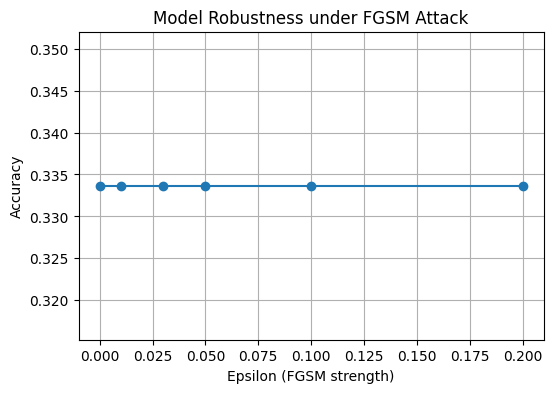

In [16]:
plt.figure(figsize=(6,4))

plt.plot(list(results.keys()), list(results.values()), marker='o')

plt.xlabel("Epsilon (FGSM strength)")
plt.ylabel("Accuracy")
plt.title("Model Robustness under FGSM Attack")
plt.grid(True)

plt.show()

Confusion Matrix Visualization:

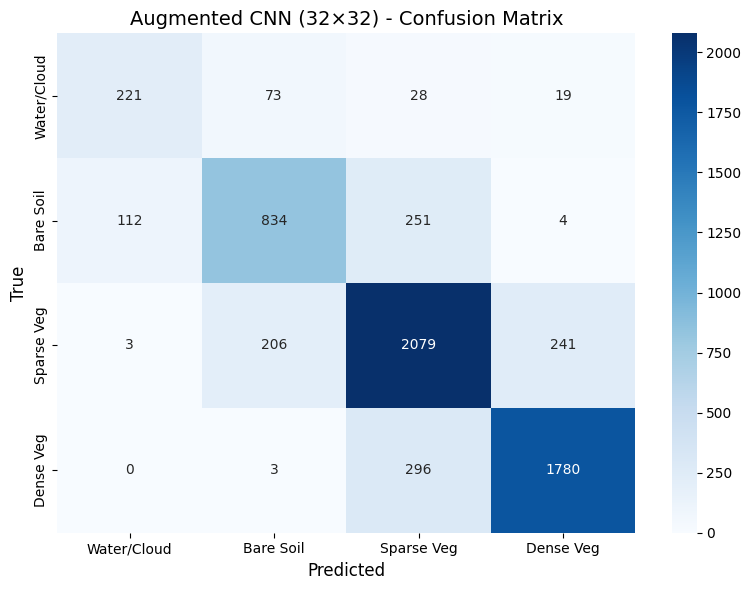

In [ ]:
class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Augmented CNN (32×32) - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('augmented_cnn_confusion_matrix.png', dpi=150)
plt.show()

Loss Curves Visualization:

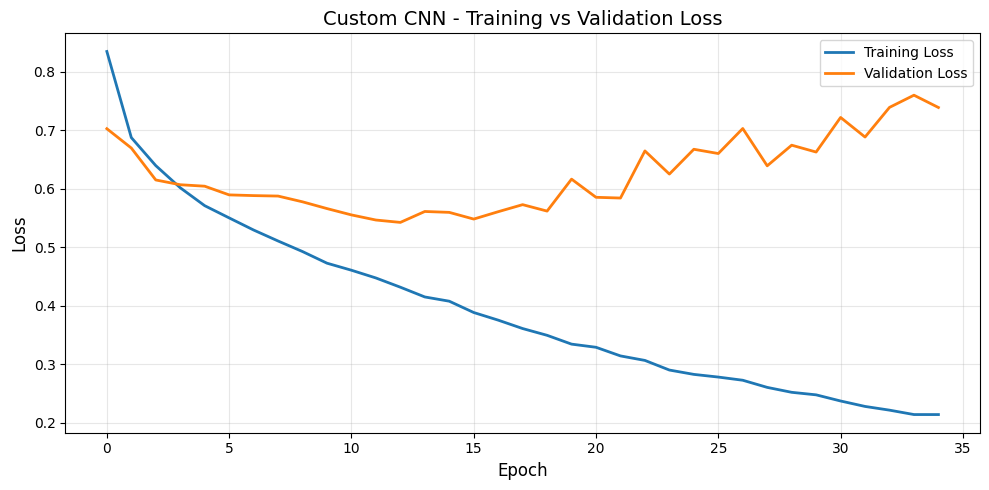

Length of train_losses: 35
Length of val_losses: 35
First 5 train losses: [0.8345685721530268, 0.6873786973301321, 0.639441020709152, 0.6016026008098075, 0.5709808177004257]
Last 5 train losses: [0.2370785286281413, 0.22777511999205066, 0.22142043796096308, 0.21389723973212918, 0.21386855521025913]
First 5 val losses: [0.7025667616387004, 0.6695006803138969, 0.6149281432333681, 0.6067836453619692, 0.6042791105730018]
Last 5 val losses: [0.7218201905488968, 0.6882903727981233, 0.7390122395968929, 0.7598535263354016, 0.7388112330713223]
Final Training Loss: 0.2139
Final Validation Loss: 0.7388

   Consider: more regularization, dropout, or early stopping

Loss curves saved to: cnn_loss_curves.png


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Custom CNN - Training vs Validation Loss', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_loss_curves.png', dpi=150)
plt.show()

print(f"Length of train_losses: {len(train_losses)}")
print(f"Length of val_losses: {len(val_losses)}")
print(f"First 5 train losses: {train_losses[:5]}")
print(f"Last 5 train losses: {train_losses[-5:]}")
print(f"First 5 val losses: {val_losses[:5]}")
print(f"Last 5 val losses: {val_losses[-5:]}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

# Check for overfitting/underfitting
if val_losses[-1] > train_losses[-1] * 1.2:
    print("\n Warning: Possible overfitting (validation loss > training loss by 20%)")
    print("   Consider: more regularization, dropout, or early stopping")
elif val_losses[-1] < train_losses[-1] * 0.8:
    print("\nWarning: Possible underfitting (validation loss < training loss)")
    print("   Consider: more epochs or a more complex model")
else:
    print("\nTraining behavior looks good - losses are balanced")

print(f"\nLoss curves saved to: cnn_loss_curves.png")

Prediction Visualizations:

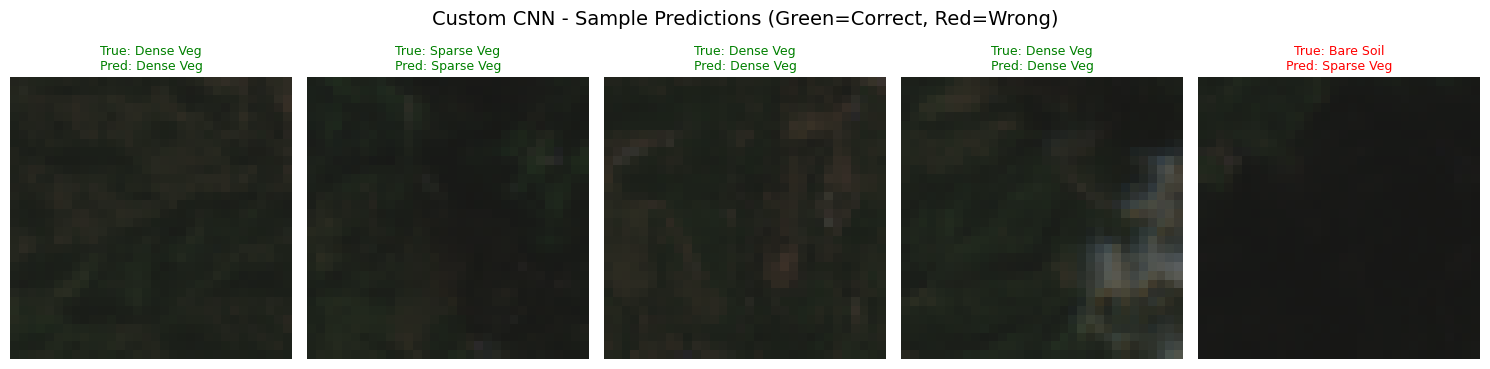


Prediction Details:
Sample 1: True=Dense Veg, Pred=Dense Veg [ CORRECT]
Sample 2: True=Sparse Veg, Pred=Sparse Veg [ CORRECT]
Sample 3: True=Dense Veg, Pred=Dense Veg [ CORRECT]
Sample 4: True=Dense Veg, Pred=Dense Veg [ CORRECT]
Sample 5: True=Bare Soil, Pred=Sparse Veg [ WRONG]

Accuracy on these 5 samples: 4/5 = 80%

Predictions visualization saved to: cnn_predictions.png


In [ ]:
model.eval()
sample_images = []
sample_labels = []
sample_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        
        for i in range(min(5, len(X_batch))):
            sample_images.append(X_batch[i].cpu())
            sample_labels.append(y_batch[i].item())
            sample_preds.append(preds[i].item())
        
        if len(sample_images) >= 5:
            break

class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']


fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, (img, true_label, pred_label) in enumerate(zip(sample_images[:5], sample_labels[:5], sample_preds[:5])):
    img_display = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_display)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Custom CNN - Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=150)
plt.show()

print("\nPrediction Details:")
correct_count = 0
for i, (true_label, pred_label) in enumerate(zip(sample_labels[:5], sample_preds[:5])):
    status = " CORRECT" if true_label == pred_label else " WRONG"
    if true_label == pred_label:
        correct_count += 1
    print(f"Sample {i+1}: True={class_names[true_label]}, Pred={class_names[pred_label]} [{status}]")

print(f"\nAccuracy on these 5 samples: {correct_count}/5 = {correct_count/5*100:.0f}%")
print(f"\nPredictions visualization saved to: cnn_predictions.png")

# Comparison

In [ ]:
svm_scores = {
    "Water/Cloud": 0.45,
    "Bare Soil": 0.61,
    "Sparse Veg": 0.76,
    "Dense Veg": 0.87,
    "Overall Acc": 0.75
}

cnn_scores = {
    "Water/Cloud": 0.53,
    "Bare Soil": 0.75,
    "Sparse Veg": 0.83,
    "Dense Veg": 0.88,
    "Overall Acc": 0.82
}

optimized_cnn_scores = {
    "Water/Cloud": 0.65,
    "Bare Soil": 0.72,
    "Sparse Veg": 0.80,
    "Dense Veg": 0.86,
    "Overall Acc": 0.80
}

print("\n" + "="*65)
print("FULL MODEL COMPARISON (F1-score per class)")
print("="*65)
print(f"{'Class':<20} {'SVM':>10} {'CNN':>12} {'Optimized CNN':>16}")
print("-"*65)

classes = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']

for cls in classes:
    print(
        f"{cls:<20} "
        f"{svm_scores[cls]:>10.2f} "
        f"{cnn_scores[cls]:>12.2f} "
        f"{optimized_cnn_scores[cls]:>16.2f}"
    )

print("-"*65)

print(
    f"{'Overall Acc':<20} "
    f"{svm_scores['Overall Acc']:>10.2f} "
    f"{cnn_scores['Overall Acc']:>12.2f} "
    f"{optimized_cnn_scores['Overall Acc']:>16.2f}"
)

print("="*65)


FULL MODEL COMPARISON (F1-score per class)
Class                       SVM          CNN    Optimized CNN
-----------------------------------------------------------------
Water/Cloud                0.45         0.53             0.65
Bare Soil                  0.61         0.75             0.72
Sparse Veg                 0.76         0.83             0.80
Dense Veg                  0.87         0.88             0.86
-----------------------------------------------------------------
Overall Acc                0.75         0.82             0.80


**ANALYSIS**:

The unoptimized CNN achieved a slightly higher reported overall accuracy compared to the optimized CNN. However, this does not necessarily indicate that it is the better model. The optimized CNN was trained under a more rigorous and controlled setup, including full dataset exposure per epoch and extended training over a larger number of epochs, making its results more reliable for evaluating true generalization performance.


When examining the training logs, it is clear that training accuracy continues to increase across epochs, while validation accuracy and validation loss begin to plateau after approximately 20 epochs. This divergence suggests the onset of overfitting, where the model continues to improve on training data but fails to meaningfully improve performance on unseen validation data.


Therefore, the optimized CNN provides a more realistic representation of model behavior, even if its final reported accuracy is slightly lower.

Importantly, the optimized CNN shows improved performance on the Water/Cloud class compared to both the unoptimized CNN and the SVM baseline. This indicates that although overall accuracy is slightly reduced, the optimized model improves classification performance on one of the most difficult and previously weakest classes, which is a meaningful improvement in class-level robustness.